# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

# 2. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/Delhi_AQIBulletins.csv')

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Sort data
df = df.sort_values('date')

# Select required columns
df = df[['date', 'index value']]

# Handle missing values
df['index value'] = df['index value'].fillna(method='ffill')

df.head()

C:\Users\gprab\AppData\Local\Temp\ipykernel_16128\4211629681.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['index value'] = df['index value'].fillna(method='ffill')


,date,index value
0,2015-05-01,221
1,2015-05-02,238
2,2015-05-03,259
3,2015-05-04,289
4,2015-05-05,311


# 3. Feature Scaling

In [3]:
scaler = StandardScaler()

df['scaled_aqi'] = scaler.fit_transform(df[['index value']])

# 4. Apply K-Means Clustering

In [4]:
# 3 clusters → low, medium, high pollution
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(df[['scaled_aqi']])

# 5. Identify Cluster Centers

In [5]:
# Convert centers back to original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

print("Cluster Centers (AQI values):\n", centers)

Cluster Centers (AQI values):
 [[359.39690722]
 [112.26252019]
 [234.3534101 ]]


# 6. Label Clusters Properly

In [6]:
# Sort clusters by AQI level
cluster_centers = centers.flatten()
sorted_idx = np.argsort(cluster_centers)

label_map = {
    sorted_idx[0]: 'Low Pollution',
    sorted_idx[1]: 'Medium Pollution',
    sorted_idx[2]: 'High Pollution'
}

df['pollution_level'] = df['cluster'].map(label_map)

# 7. Visualize Cluster Distribution

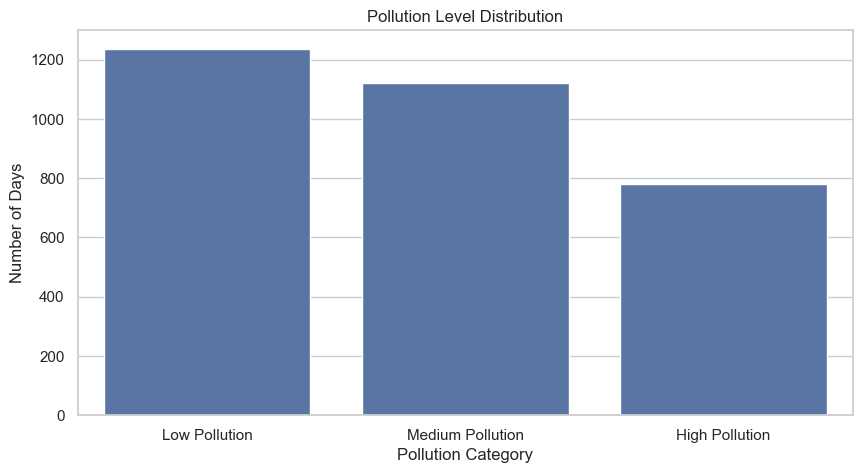

In [7]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='pollution_level', order=['Low Pollution','Medium Pollution','High Pollution'])

plt.title("Pollution Level Distribution")
plt.xlabel("Pollution Category")
plt.ylabel("Number of Days")

plt.show()

# 8. Scatter Plot (Cluster Visualization)

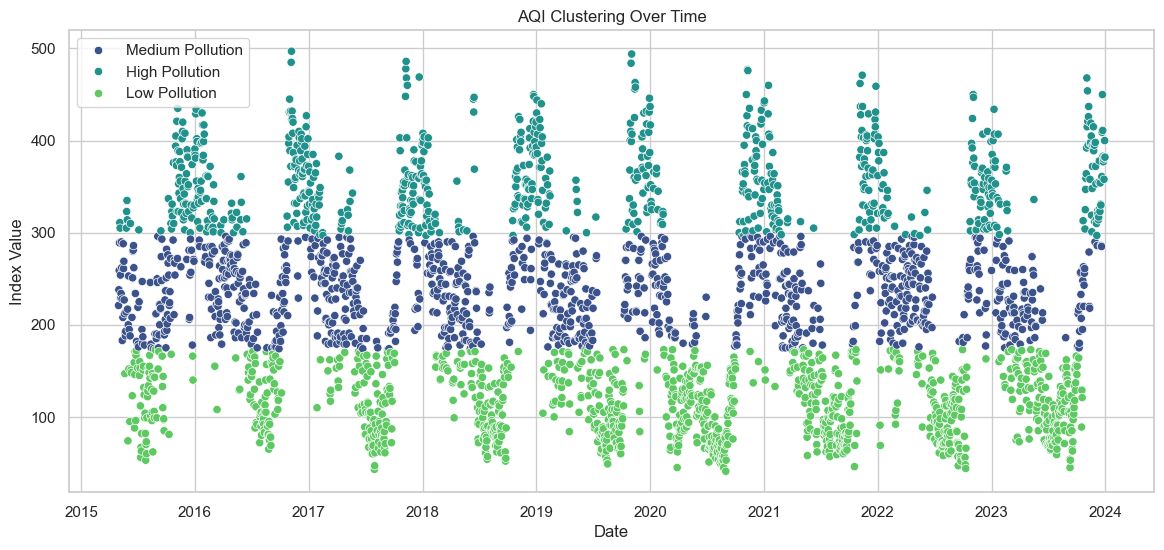

In [8]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    x=df['date'],
    y=df['index value'],
    hue=df['pollution_level'],
    palette='viridis'
)

plt.title("AQI Clustering Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.legend()
plt.show()

# 9. Boxplot for Cluster Interpretation

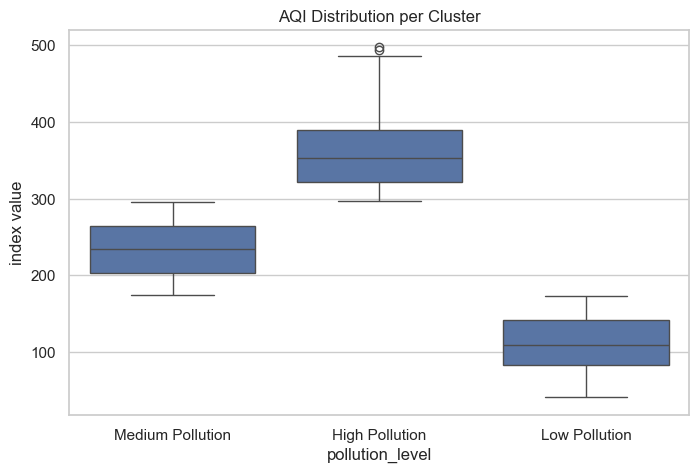

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x='pollution_level', y='index value', data=df)

plt.title("AQI Distribution per Cluster")
plt.show()

# 10. Cluster Interpretation (IMPORTANT)

In [10]:
df.groupby('pollution_level')['index value'].describe()

,count,mean,std,min,25%,50%,75%,max
pollution_level,,,,,,,,
High Pollution,782.0,358.918159,43.124196,297.0,322.0,353.0,389.0,497.0
Low Pollution,1238.0,112.262520,34.460054,41.0,83.0,110.0,142.0,173.0
Medium Pollution,1123.0,234.018700,35.498922,174.0,203.0,234.0,264.0,296.0


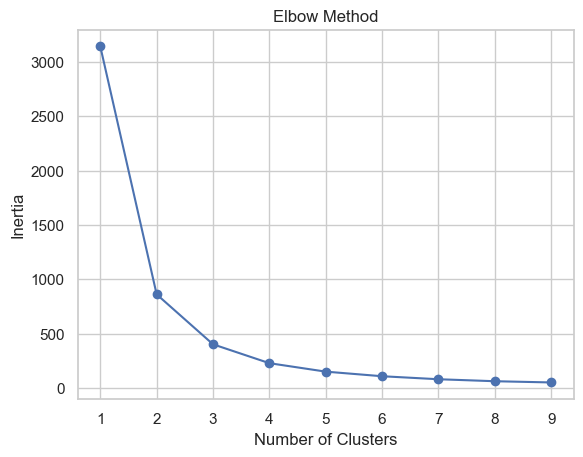

In [11]:
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df[['scaled_aqi']])
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()